In [1]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm
import copy
import torch
from utils import *
from matplotlib.ticker import AutoMinorLocator, ScalarFormatter
from ipywidgets import interact, IntSlider


def wavesubsidence(w_wave, dse, qbg, z, zi):
    """
    Function to compute T and q tendencies from vertical advection

    Inputs:
        w_wave: vertical velocity associated with the large-scale wave
        dse: background profiles of dry static energy divided by Cp
        qbg: background profiles of specific humidity
        z: cell center height
        zi: interface height

    Outputs:
        ttend, qtend: temperature and moisture tendencies
    """
    nz = len(z)  # number of layers
    ttend = np.zeros(nz)
    qtend = np.zeros(nz)

    # centered difference
    for k in range(1, nz - 1):
        ttend[k] = -w_wave[k] * (dse[k + 1] - dse[k - 1]) / (z[k + 1] - z[k - 1])
        qtend[k] = -w_wave[k] * (qbg[k + 1] - qbg[k - 1]) / (z[k + 1] - z[k - 1])

    # one-sided difference
    ttend[0] = -w_wave[0] * (dse[1] - dse[0]) / (z[1] - z[0])
    ttend[-1] = -w_wave[-1] * (dse[-1] - dse[-2]) / (z[-1] - z[-2])
    qtend[0] = -w_wave[0] * (qbg[1] - qbg[0]) / (z[1] - z[0])
    qtend[-1] = -w_wave[-1] * (qbg[-1] - qbg[-2]) / (z[-1] - z[-2])

    return ttend, qtend


def advancew(t_wave, z, zi, rho, w_wave, t_wavebg, wavenumber_factor):
    """
    Function to compute vertical velocity tendencies from vertical advection

    Inputs:
        t_wave: anomalous associated with the large-scale wave
        z: cell center height
        zi: interface height
        rho: cell center density
        w_wave: vertical velocity
        t_wavebg: reference temperature profile
        wavenumber_factor: controls the horizontal wavenumber. A value of 1 gives a wavelength of 1000km

    Outputs:
        wtend: vertical velocity tendency
    """
    ggr = 9.8  # gravity
    Cp = 1004.0
    wn = wavenumber_factor * 6.283e-6
    wn2 = wn * wn

    nz = len(z)
    adz = np.zeros(nz + 1)

    for k in range(1, nz):
        adz[k] = z[k] - z[k - 1]
    adz[0] = 2 * z[0]
    adz[-1] = 2 * (zi[-1] - z[-1])

    # Gauss Elimination
    rhs = np.zeros(nz)
    for k in range(nz):
        rhs[k] = -rho[k] * ggr * wn2 * t_wave[k] / t_wavebg[k] * adz[k] * adz[k + 1] / 2.

    # Set up the tridiagonal matrix
    aa = adz[1:] / (adz[:-1] + adz[1:])
    bb = -np.ones(nz)
    cc = adz[:-1] / (adz[:-1] + adz[1:])

    # Symmetric lower BC
    aa[0] = 0
    bb[0] = -(2 * adz[1] + adz[0]) / (adz[0] + adz[1])

    # Radiating upper BC
    N2top = ggr / t_wavebg[-1] * ((t_wavebg[-1] - t_wavebg[-2]) / (z[-1] - z[-2]) + ggr / Cp)
    aa[-1] = adz[-1] / adz[-2]
    bb[-1] = -adz[-1] / adz[-2]
    rhs[-1] = rhs[-1] + np.sqrt(N2top) * rho[-1] * wn * w_wave[-1] * adz[-1]

    # Gaussian Elimination with no pivoting
    for k in range(nz - 1):
        bb[k + 1] = bb[k + 1] - aa[k + 1] / bb[k] * cc[k]
        rhs[k + 1] = rhs[k + 1] - aa[k + 1] / bb[k] * rhs[k]
    # Backward substitution
    rhs[-1] = rhs[-1] / bb[-1]
    for k in range(nz - 2, -1, -1):
        rhs[k] = (rhs[k] - cc[k] * rhs[k + 1]) / bb[k]
    wtend = rhs / rho
    return wtend

def load_grd_var():
    # Load profile data
    nc_file = '../data/RCE_randmultsine_spinup_256_0_3.nc'
    data = nc.Dataset(nc_file)
    t_wavebg = data.variables['TABS'][:, :].mean(axis=0)
    q_wavebg = data.variables['QV'][:, :].mean(axis=0)
    p = data.variables['p'][:]
    pres = p.squeeze()
    rho = data.variables['RHO'][-1, :].squeeze()
    print(rho)
    z = data.variables['z'][:]
    data.close()
    
    # Virtual temperature profile
    tv_wavebg = t_wavebg * (1 + 0.61 * q_wavebg / 1000)
    
    nzm = len(z)
    nz = nzm + 1
    ggr = 9.8
    
    # Density at interface levels in kg/m^3
    #rhow = np.zeros(nz)
    #for k in range(1, nzm):
    #    rhow[k] = (pres[k - 1] - pres[k]) / (z[k] - z[k - 1]) / ggr * 100
    #
    #rhow[0] = 2 * rhow[1] - rhow[2]
    #rhow[nz - 1] = 2 * rhow[nzm - 1] - rhow[nzm - 2]
    #print(rhow)
    
    dz = 0.5 * (z[0] + z[1])
    adzw = np.zeros(nz)
    adz = np.zeros(nzm)
    for k in range(1, nzm):
        adzw[k] = (z[k] - z[k - 1]) / dz
    
    adzw[0] = 1
    adzw[nz - 1] = adzw[nzm - 1]
    
    adz[0] = 1
    for k in range(1, nzm-1):
        adz[k] = 0.5 * (z[k + 1] - z[k - 1]) / dz
    
    adz[nzm - 1] = adzw[nzm - 1]
    
    # Interface heights
    zi = np.zeros(nz)
    for k in range(1, nz):
        zi[k] = zi[k - 1] + adz[k - 1] * dz
    
    gamaz = z * ggr / 1004.  # Potential energy part of the dry static energy (divided by cp)
    
    return {'z': z, 'zi': zi, 'pres': pres, 't_wavebg': t_wavebg, 'q_wavebg': q_wavebg, 'tv_wavebg': tv_wavebg, 'rho': rho, 'gamaz': gamaz}

def load_params():
    # Read in mass in each layer
    dm = np.loadtxt('IDEAL_dm.txt')
    nT = 26
    nQ = 14
    # Weight variance by mass
    mass_weight = np.diag(np.sqrt(np.concatenate([dm[:nT], (2.5 ** 2) * dm[:nQ], [1.]])))
    
    A, B, C = read_params_from_ssm(64, input_size=40, output_size=41, name_fix="addp_4x")
    return {'A':A, 'B':B, 'C':C, 'mass_weight':mass_weight}

def ReLU(array):
    tmp = array
    tmp[tmp<0] = 0
    return tmp

def input_layer_nonlinear(params, state, input):
    # nonlinear component of state evolution
    tmp1 = ReLU(params['input_layer_1.weight'].numpy() @ np.concatenate((state, input), axis=0) + params['input_layer_1.bias'].numpy()[:, np.newaxis])
    tmp2 = ReLU(params['input_layer_2.weight'].numpy() @ tmp1 + params['input_layer_2.bias'].numpy()[:, np.newaxis])
    tmp3 = params['input_layer_3.weight'].numpy() @ tmp2 + params['input_layer_3.bias'].numpy()[:, np.newaxis]
    #assert tmp3.shape==(60, 1)
    return tmp3

def esatw(t):
    # saturation vapor pressure
    # Constants (same values as in the Fortran code)
    a0 = 6.11239921
    a1 = 0.443987641
    a2 = 0.142986287e-1
    a3 = 0.264847430e-3
    a4 = 0.302950461e-5
    a5 = 0.206739458e-7
    a6 = 0.640689451e-10
    a7 = -0.952447341e-13
    a8 = -0.976195544e-15

    # Temperature difference calculation
    dt = max(-80.0, t - 273.16)

    # Compute esatw using the polynomial expression
    esatw = (a0 + dt * (a1 + dt * (a2 + dt * (a3 + dt * (a4 + dt * 
            (a5 + dt * (a6 + dt * (a7 + a8 * dt))))))))

    return esatw

def qsatw(t, p):
    # saturation specific humidity
    # Calculate esat using the esatw function
    esat = esatw(t)
    
    # Calculate qsatw using the formula
    qsatw_value = 0.622 * esat / max(esat, p - esat)
    return qsatw_value

ssq = qsatw(302.15, 1005.50)

In [2]:
# load grid variables
print('Loading grid variables...')
grd_var = load_grd_var()
z = grd_var['z']
zi = grd_var['zi']
rho = grd_var['rho']
t_wavebg = grd_var['t_wavebg']
q_wavebg = grd_var['q_wavebg']
tv_wavebg = grd_var['tv_wavebg']
gamaz = grd_var['gamaz']
# load params
#print('Loading model parameters...')
nT = 26
nQ = 14
dm = np.loadtxt('IDEAL_dm.txt')
linear_params = load_params()
A = linear_params['A']
B = linear_params['B']
C = linear_params['C']
mass_weight = linear_params['mass_weight']

loadmodel = './logs/rand_4_to_50_seqlen_192_skip_48_noisywave1.0_6to20_damp2_seqlen_192_skip_24_all_param_2e-06_256/version_0/checkpoints/epoch=4899-val_loss=0.094.ckpt'

checkpoint = torch.load(loadmodel, map_location=torch.device('cpu'))
nonlinear_params = checkpoint['state_dict']

def test_model(h0, wavenumber_factor=0.25, wavedamping_time=1.0, wavetqdamping_time=None, nday=200):
    # local parameters
    dt = 900
    nout = 1
    if wavetqdamping_time is None:
        wavetqdamping_time = wavedamping_time
    wn = wavenumber_factor * 6.283e-6  # 2pi/1000km wavenumber
    nzm = len(z)
    nz = nzm + 1
    nt = int(86400 * nday / dt)
    time = np.arange(0, nt, nout) * dt / 86400

    #print('Initializing outputs...')
    rainfall = 0
    
    # Define variables T, q, w
    tout = np.zeros((nzm, nt // nout))
    qout = np.zeros((nzm, nt // nout))
    wout = np.zeros((nzm, nt // nout))
    q1cout = np.zeros((nzm, nt // nout))
    q2out = np.zeros((nzm, nt // nout))
    ttendout = np.zeros((nzm, nt // nout))
    qtendout = np.zeros((nzm, nt // nout))
    precout = np.zeros(nt // nout)
    iprecout = np.zeros(nt // nout)
    iprecout_ml = np.zeros(nt // nout)
    
    # Convective tendencies
    ttend_conv = np.zeros((nzm, 1))
    qtend_conv = np.zeros((nzm, 1))
    
    # Initialize with random noise
    #print('Initializing states...')
    nx = A.shape[0]
    x = h0.reshape(nx, 1)
    y = np.dot(np.linalg.solve(mass_weight, C), x)
    
    xout = np.zeros((nx, nt // nout))
    yout = np.zeros((nT+nQ+1, nt // nout))
    iout = np.zeros((nT+nQ, nt // nout))

    yinit = y.squeeze()
    newt = np.zeros(nzm)
    newq = np.zeros(nzm)
    neww = np.zeros(nzm)
    newt[:nT] = yinit[:nT]
    newq[:nQ] = yinit[nT:nT+nQ]
    
    tout[:, 0] = copy.deepcopy(newt.squeeze())
    qout[:, 0] = copy.deepcopy(newq.squeeze())
    wout[:, 0] = copy.deepcopy(neww.squeeze())

    xout[:, 0] = copy.deepcopy(x[:, 0])
    yout[:, 0] = copy.deepcopy(yinit[:])
    # Define functions and perform integration
    # Integrate model over time
    #print('Starting intergration...')
    for it in range(1, nt):
        oldt = copy.deepcopy(newt)
        oldq = copy.deepcopy(newq)
        oldw = copy.deepcopy(neww)
    
        # Extract current T and q
        y = np.dot(np.linalg.solve(mass_weight, C), x)
        newt[:nT] = y[:nT].squeeze()
        newq[:nQ] = y[nT:nT+nQ].squeeze()
        # Vertical advective tendencies using the current w
        t_tend, q_tend = wavesubsidence(oldw[:-1], t_wavebg[:-1] + gamaz[:-1] + newt[:-1],
                                        q_wavebg[:-1] + newq[:-1], z[:-1], zi[:-1])
        #print(oldw, t_tend)
        # The top two layers are excluded as in SAM
        t_tend = np.concatenate((t_tend, np.zeros(1)))
        q_tend = np.concatenate((q_tend, np.zeros(1)))
    
        # Include T and q damping
        t_tend = t_tend - newt / 86400 / wavetqdamping_time
        q_tend = q_tend - newq / 86400 / wavetqdamping_time
        # Apply upper boundary nudging to the top two layers as in SAM
        newt[nT:] = oldt[nT:] + t_tend[nT:] * dt
        newt[-2:] = newt[-2:] - oldt[-2:] * dt / 3600
        newq[nQ:] = oldq[nQ:] + q_tend[nQ:] * dt
        newq[-2:] = newq[-2:] - oldq[-2:] * dt / 3600
        # Diagnostic output
        ttend_conv = (newt - oldt) / dt - t_tend
        qtend_conv = (newq - oldq) / dt - q_tend
    
        # Update the state vector
        input_t = mass_weight[:nT+nQ, :nT+nQ] @ np.concatenate((t_tend[:nT], q_tend[:nQ]))[:, np.newaxis] * dt
        
        x_linear = np.dot(A, x) + np.dot(B, input_t)
        x_nonlinear = input_layer_nonlinear(nonlinear_params, x, input_t)
        x = x_linear + x_nonlinear
        
        # Update w
        tv_wave = (t_wavebg + newt) * (1 + 0.61 * (q_wavebg + newq) / 1000) - tv_wavebg
        wtend = advancew(tv_wave[:-2], z[:-2], zi[:-2], rho[:-2], oldw[:-2], tv_wavebg[:-2], wavenumber_factor)
        neww[:-2] = (1 - dt / 86400 / wavedamping_time) * oldw[:-2] + wtend * dt

        # diagnose from changes in vapor, not used because changes in condensed water also matter
        rainfall -= np.sum(qtend_conv * dm) * 86400 * 100 / 1e3
        irainfall_ml = np.exp(y[-1].squeeze()+1.45244)
    
        # Output
        if it % nout == 0:
            #print(f'Current time step = {it}')
            tout[:, it // nout] = oldt.copy()
            qout[:, it // nout] = oldq.copy()
            wout[:, it // nout] = -neww * rho * 10  # Output omega instead of w
            q1cout[:, it // nout] = ttend_conv * 86400  # Convective Q1 (K/day)
            q2out[:, it // nout] = qtend_conv * 86400
            ttendout[:, it // nout] = t_tend * 86400
            qtendout[:, it // nout] = q_tend * 86400
            # accumulative rainfall
            precout[it // nout] = rainfall/nout
            rainfall = 0
            # instantaneous rainfall
            iprecout[it // nout] = -np.sum(qtend_conv * dm) * 86400 * 100 / 1e3
            iprecout_ml[it // nout] = irainfall_ml
            xout[:, it // nout] = x[:, 0].copy()
            yout[:, it // nout] = y[:, 0].copy()
            iout[:, it // nout] = input_t[:, 0].copy()
    #print('Model run finished...')
    # integrate results
    #print('Integrating results...')
    params = {'wavenumber_factor':wavenumber_factor, 'wavedamping_time':wavedamping_time, 'wavetqdamping_time':wavetqdamping_time,
               'nday':nday}
    grd_var['time'] = time
    grd_var['nday'] = nday
    grd_var['dt'] = dt
    results = {
        'tout': tout,
        'qout': qout,
        'wout': wout,
        'precout': precout,
        'iprecout_ml': iprecout_ml,
        'xout': xout,
        'yout': yout,
        'iout': iout,
        'q1cout': q1cout,
        'q2out': q2out,
        'ttendout': ttendout,
        'qtendout': qtendout
    }
    
    return params, grd_var, results

Loading grid variables...
[1.1645187  1.1506182  1.134073   1.1141845  1.0934285  1.0684571
 1.0394335  0.9978878  0.93941116 0.8657528  0.7800001  0.6909725
 0.6069689  0.5334224  0.47027734 0.415651   0.36783764 0.32514447
 0.28593725 0.2486199  0.2089714  0.1729     0.14170638 0.11321981
 0.08332584 0.05432124 0.02960239 0.01515645]


In [4]:
from scipy.optimize import differential_evolution

In [5]:
def loss_wn10(x, target):
    _, _, results = test_model(x, wavenumber_factor=0.25, wavedamping_time=2.0, wavetqdamping_time=None, nday=6)
    output = results['iprecout_ml']
    # Exclude the first element when computing error
    loss_val = np.sum((output[10:] - target[10:])**2)
    #print(x, loss_val)
    return loss_val

def loss_wn20(x, target):
    _, _, results = test_model(x, wavenumber_factor=0.5, wavedamping_time=2.0, wavetqdamping_time=None, nday=6)
    output = results['iprecout_ml']
    # Exclude the first element when computing error
    loss_val = np.sum((output[10:] - target[10:])**2)
    #print(x, loss_val)
    return loss_val

In [6]:
SAMdata = nc.Dataset(f'../data/foronline/RCE_noisywave_wn10_damp2day_noadvectbg_noiselevel_0.0_1_1.nc', 'r')
SAM_p = SAMdata['PREC'][:]
bounds = [(-0.02, 0.02)] * 64
result = differential_evolution(lambda x: loss_wn10(x, SAM_p[:576]), bounds, disp=True, maxiter=5, popsize=3, polish=False)
optimal_input_wn10_1 = result.x
SAMdata = nc.Dataset(f'../data/foronline/RCE_noisywave_wn10_damp2day_noadvectbg_noiselevel_0.0_2_1.nc', 'r')
SAM_p = SAMdata['PREC'][:]
bounds = [(-0.02, 0.02)] * 64
result = differential_evolution(lambda x: loss_wn10(x, SAM_p[:576]), bounds, disp=True, maxiter=5, popsize=3, polish=False)
optimal_input_wn10_2 = result.x

differential_evolution step 1: f(x)= 314.874
differential_evolution step 2: f(x)= 239.572
differential_evolution step 3: f(x)= 239.572
differential_evolution step 4: f(x)= 239.572
differential_evolution step 5: f(x)= 239.572
differential_evolution step 1: f(x)= 297.906
differential_evolution step 2: f(x)= 297.906
differential_evolution step 3: f(x)= 297.906
differential_evolution step 4: f(x)= 297.906
differential_evolution step 5: f(x)= 297.906


In [7]:
print(optimal_input_wn10_1)
print(optimal_input_wn10_2)

[-1.21687288e-02  1.85164838e-02  1.27767474e-02  6.61536655e-03
 -2.93830338e-04  1.73871153e-02  6.67753531e-04 -1.12072397e-02
  3.20891833e-04 -6.22409733e-04 -1.35325964e-02  8.52274392e-03
 -7.90401854e-03 -1.80572515e-03 -8.88284533e-03 -7.25077002e-03
 -2.15121942e-03  1.37720529e-02 -6.48083878e-03  1.11987966e-02
 -2.99406433e-03  3.72697068e-03 -1.84388204e-02 -5.11233927e-04
  5.84939273e-03  1.20086308e-02  7.18858999e-03 -1.17927955e-02
  9.23350224e-03 -2.98151740e-04  1.24517981e-02 -4.13227721e-05
  3.35652986e-04  1.22803651e-02  1.26774078e-02  8.00677874e-03
  2.34599536e-03 -1.81029314e-03  8.66140888e-03  9.67801876e-04
  1.95911537e-02 -8.08485801e-03 -1.48512520e-02 -1.57383329e-02
  7.55632205e-03 -1.80056864e-02 -6.28380300e-03  1.11142558e-02
 -8.72304337e-03  3.94151798e-03  1.03172561e-02 -7.39624084e-04
 -7.12198570e-03  2.24115931e-03 -1.38217766e-03 -6.78481440e-03
 -1.48502018e-02  8.84782787e-03  8.80692249e-04 -2.14026486e-03
  2.25280500e-03  7.97532

In [8]:
SAMdata = nc.Dataset(f'../data/foronline/RCE_noisywave_wn20_damp2day_noadvectbg_noiselevel_0.0_1_1.nc', 'r')
SAM_p = SAMdata['PREC'][:]
bounds = [(-0.005, 0.005)] * 64
result = differential_evolution(lambda x: loss_wn20(x, SAM_p[:576]), bounds, disp=True, maxiter=5, popsize=3, polish=False)
optimal_input_wn20_1 = result.x
SAMdata = nc.Dataset(f'../data/foronline/RCE_noisywave_wn20_damp2day_noadvectbg_noiselevel_0.0_2_1.nc', 'r')
SAM_p = SAMdata['PREC'][:]
bounds = [(-0.005, 0.005)] * 64
result = differential_evolution(lambda x: loss_wn20(x, SAM_p[:576]), bounds, disp=True, maxiter=5, popsize=3, polish=False)
optimal_input_wn20_2 = result.x

differential_evolution step 1: f(x)= 397.874
differential_evolution step 2: f(x)= 334.877
differential_evolution step 3: f(x)= 334.877
differential_evolution step 4: f(x)= 334.877
differential_evolution step 5: f(x)= 334.877
differential_evolution step 1: f(x)= 476.126
differential_evolution step 2: f(x)= 422.539
differential_evolution step 3: f(x)= 398.499
differential_evolution step 4: f(x)= 398.499
differential_evolution step 5: f(x)= 394.017


In [9]:
print(optimal_input_wn20_1)
print(optimal_input_wn20_2)

[ 0.00354616 -0.00226773  0.00204098  0.00462641  0.00379204 -0.00250491
 -0.00382821 -0.00091178 -0.00126126 -0.00246652 -0.0019634  -0.00209563
 -0.00192465  0.00182665 -0.00370517  0.00239885  0.00193627  0.00333662
  0.00147493 -0.00107543  0.00207729 -0.00378635 -0.0027726   0.00021813
  0.00183045 -0.00194773 -0.00290815 -0.0048459  -0.00360595  0.00327243
 -0.00419043 -0.00032798  0.00371436 -0.00222671  0.00205676  0.00414739
  0.00306139 -0.00178095  0.00349179 -0.00379221  0.00256361  0.00217799
 -0.00330009 -0.00413373  0.00376856  0.002773   -0.00027501 -0.00293797
 -0.00180386  0.00063744 -0.00252025 -0.00435178 -0.00447942  0.00306956
 -0.00258036 -0.00119976 -0.00234741  0.0018076  -0.00379209 -0.00239266
  0.00094727  0.00498522  0.00051865  0.00411263]
[ 0.0001739  -0.00160765  0.00184583  0.00290722  0.00206785  0.00014474
 -0.00266135  0.00257207  0.00155578  0.00247638 -0.00399602  0.00108458
 -0.00068658  0.00458238 -0.00396603  0.00069964  0.00247673 -0.00393979
 

In [10]:
spinup_dataset = nc.Dataset('../data/RCE_noisywave_spinup_2_3.nc', 'r')
spinup_P = spinup_dataset['PREC'][:]
spinup_LOGP_mean = np.mean(np.log(spinup_P+1e-6))
spinup_T = spinup_dataset['TABS'][:, :].astype(float)
spinup_Q = spinup_dataset['QV'][:, :].astype(float)

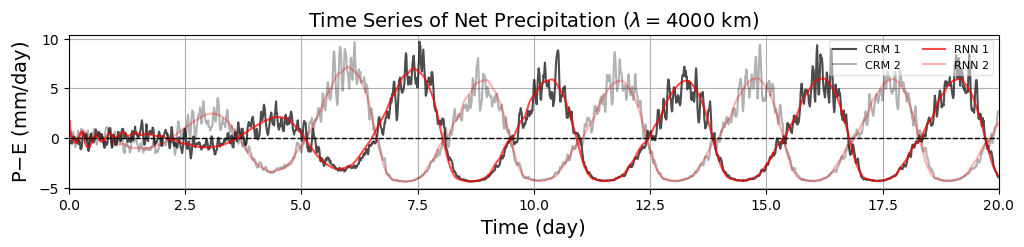

In [11]:
plt.figure(figsize=(12, 2))
SAMdata = nc.Dataset(f'../data/foronline/RCE_noisywave_wn10_damp2day_noadvectbg_noiselevel_0.0_1_1.nc', 'r')
SAM_p = SAMdata['PREC'][:]
SAM_e = SAMdata['LHF'][:] / 2.5e6 * 86400
SAM_p = SAM_p - SAM_e
plt.plot(np.arange(20*96)/96., SAM_p[:20*96], 'k', alpha=0.7, label='CRM 1')

SAMdata = nc.Dataset(f'../data/foronline/RCE_noisywave_wn10_damp2day_noadvectbg_noiselevel_0.0_2_1.nc', 'r')
SAM_p = SAMdata['PREC'][:]
SAM_e = SAMdata['LHF'][:] / 2.5e6 * 86400
SAM_p = SAM_p - SAM_e
plt.plot(np.arange(20*96)/96., SAM_p[:20*96], 'k', alpha=0.3, label='CRM 2')

_, _, results = test_model(optimal_input_wn10_1, wavenumber_factor=0.25, wavedamping_time=2.0, wavetqdamping_time=None, nday=20)
delq = spinup_Q[:, 0].mean()/1000. + results['qout'][0, :] / 1000. - ssq
cd = 1.1e-3
windspeed = 5.
wrk = (np.log(10/1.e-4) / np.log(spinup_dataset['z'][0]/1.e-4))**2
evap_diag = -cd*windspeed*delq*wrk * 86400 * 1.173
plt.plot(np.arange(20*96)/96., results['iprecout_ml'] - evap_diag, 'r', alpha=0.7, label='RNN 1')

_, _, results = test_model(optimal_input_wn10_2, wavenumber_factor=0.25, wavedamping_time=2.0, wavetqdamping_time=None, nday=20)
delq = spinup_Q[:, 0].mean()/1000. + results['qout'][0, :] / 1000. - ssq
evap_diag = -cd*windspeed*delq*wrk * 86400 * 1.173
plt.plot(np.arange(20*96)/96., results['iprecout_ml'] - evap_diag, 'r', alpha=0.3, label='RNN 2')

plt.gca().axhline(y=0, linestyle='--', color='k', linewidth=1)
plt.xlim(0, 20)
plt.xlabel('Time (day)', fontsize=14)
plt.ylabel('P$-$E (mm/day)', fontsize=14)
plt.title(r'Time Series of Net Precipitation ($\lambda=4000~\mathrm{km}$)', fontsize=14)
plt.legend(loc='upper right', ncol=2, fontsize=8, framealpha=0.5)
plt.grid()



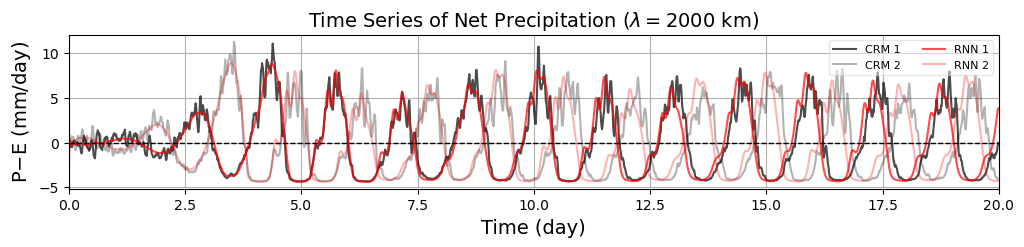

In [12]:
plt.figure(figsize=(12, 2))
SAMdata = nc.Dataset(f'../data/foronline/RCE_noisywave_wn20_damp2day_noadvectbg_noiselevel_0.0_1_1.nc', 'r')
SAM_p = SAMdata['PREC'][:]
SAM_e = SAMdata['LHF'][:] / 2.5e6 * 86400
SAM_p = SAM_p - SAM_e
plt.plot(np.arange(20*96)/96., SAM_p[:20*96], 'k', alpha=0.7, label='CRM 1')

SAMdata = nc.Dataset(f'../data/foronline/RCE_noisywave_wn20_damp2day_noadvectbg_noiselevel_0.0_2_1.nc', 'r')
SAM_p = SAMdata['PREC'][:]
SAM_e = SAMdata['LHF'][:] / 2.5e6 * 86400
SAM_p = SAM_p - SAM_e
plt.plot(np.arange(20*96)/96., SAM_p[:20*96], 'k', alpha=0.3, label='CRM 2')

_, _, results = test_model(optimal_input_wn20_1, wavenumber_factor=0.5, wavedamping_time=2.0, wavetqdamping_time=None, nday=20)
delq = spinup_Q[:, 0].mean()/1000. + results['qout'][0, :] / 1000. - ssq
cd = 1.1e-3
windspeed = 5.
wrk = (np.log(10/1.e-4) / np.log(spinup_dataset['z'][0]/1.e-4))**2
evap_diag = -cd*windspeed*delq*wrk * 86400 * 1.173
plt.plot(np.arange(20*96)/96., results['iprecout_ml'] - evap_diag, 'r', alpha=0.7, label='RNN 1')

_, _, results = test_model(optimal_input_wn20_2, wavenumber_factor=0.5, wavedamping_time=2.0, wavetqdamping_time=None, nday=20)
delq = spinup_Q[:, 0].mean()/1000. + results['qout'][0, :] / 1000. - ssq
evap_diag = -cd*windspeed*delq*wrk * 86400 * 1.173
plt.plot(np.arange(20*96)/96., results['iprecout_ml'] - evap_diag, 'r', alpha=0.3, label='RNN 2')

plt.gca().axhline(y=0, linestyle='--', color='k', linewidth=1)
plt.xlim(0, 20)
plt.xlabel('Time (day)', fontsize=14)
plt.ylabel('P$-$E (mm/day)', fontsize=14)
plt.title(r'Time Series of Net Precipitation ($\lambda=2000~\mathrm{km}$)', fontsize=14)
plt.legend(loc='upper right', ncol=2, fontsize=8, framealpha=0.5)
plt.grid()